In [3]:
# ===============================
# Import Required Libraries
# ===============================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)

import shap

In [7]:
# ===============================
# Load Dataset
# ===============================

df = pd.read_csv("../data/project_train_data.csv")

print("Dataset loaded successfully!")


# ===============================
# Check Dataset Size
# ===============================

print("Rows and Columns:", df.shape)

Dataset loaded successfully!
Rows and Columns: (104805, 12)


In [8]:

# View Dataset Structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104805 entries, 0 to 104804
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Id                                    104805 non-null  int64  
 1   SeriousDlqin2yrs                      104805 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  104805 non-null  float64
 3   age                                   104805 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  104805 non-null  int64  
 5   DebtRatio                             104805 non-null  float64
 6   MonthlyIncome                         84024 non-null   float64
 7   NumberOfOpenCreditLinesAndLoans       104805 non-null  int64  
 8   NumberOfTimes90DaysLate               104805 non-null  int64  
 9   NumberRealEstateLoansOrLines          104805 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  104805 non-null  int64  
 11  

In [9]:
# ===============================
# Preview the Dataset
# ===============================

df.head()

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
1,2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
2,3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
3,4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
4,5,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0


In [10]:
# ===============================
# Check Target Distribution
# ===============================

df["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    97855
1     6950
Name: count, dtype: int64

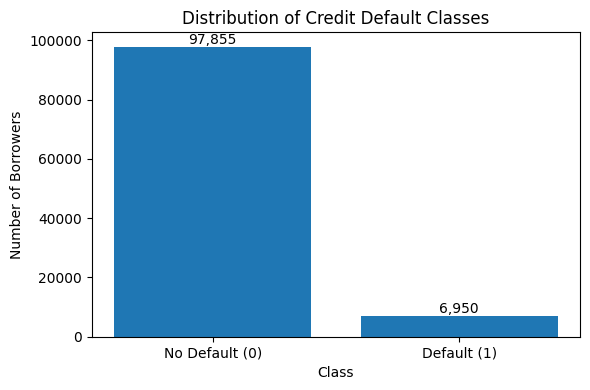

In [11]:
# ===============================
# Visualize Target Distribution
# ===============================

import matplotlib.pyplot as plt

# Count the classes
class_counts = df["SeriousDlqin2yrs"].value_counts().sort_index()

# Create the figure
plt.figure(figsize=(6,4))
bars = plt.bar(
    ["No Default (0)", "Default (1)"],
    class_counts.values
)

# Labels
plt.title("Distribution of Credit Default Classes")
plt.xlabel("Class")
plt.ylabel("Number of Borrowers")

# Add values on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [12]:
# ===============================
# Remove ID and Handle Missing Values
# ===============================

# Make a copy of the dataset
df_clean = df.copy()

# Remove ID column
df_clean = df_clean.drop(columns=["Id"])

# Fill missing values with the median
df_clean["MonthlyIncome"] = df_clean["MonthlyIncome"].fillna(
    df_clean["MonthlyIncome"].median()
)

df_clean["NumberOfDependents"] = df_clean["NumberOfDependents"].fillna(
    df_clean["NumberOfDependents"].median()
)

print("Cleaning completed successfully.")

Cleaning completed successfully.


In [13]:
df_clean.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

In [14]:
# ===============================
# Split Features and Target
# ===============================

# Features (X)
X = df_clean.drop(columns=["SeriousDlqin2yrs"])

# Target (y)
y = df_clean["SeriousDlqin2yrs"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (83844, 10)
Testing set : (20961, 10)


In [15]:
# ===============================
# Train Gradient Boosting Model
# ===============================

model = GradientBoostingClassifier(
    random_state=42
)

model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [16]:
# ===============================
# Evaluate Model Performance
# ===============================

# Predictions
y_pred = model.predict(X_test)

# Prediction probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

Accuracy : 0.9384
Precision: 0.6102
Recall   : 0.1971
F1-score : 0.2980
ROC-AUC  : 0.8661


In [17]:
# ===============================
# Create SHAP Explainer
# ===============================

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [18]:
# ===============================
# Compute SHAP Values
# ===============================

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

print("SHAP values computed successfully.")

SHAP values computed successfully.


In [19]:
# ===============================
# Calculate Mean Absolute SHAP Importance
# ===============================

# Calculate mean absolute SHAP value for each feature
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_SHAP": np.abs(shap_values).mean(axis=0)
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Mean_SHAP",
    ascending=False
)

feature_importance

,Feature,Mean_SHAP
0,RevolvingUtilizationOfUnsecuredLines,0.576666
2,NumberOfTime30-59DaysPastDueNotWorse,0.259902
6,NumberOfTimes90DaysLate,0.216386
1,age,0.211223
5,NumberOfOpenCreditLinesAndLoans,0.114624
8,NumberOfTime60-89DaysPastDueNotWorse,0.110880
4,MonthlyIncome,0.078046
3,DebtRatio,0.068698
7,NumberRealEstateLoansOrLines,0.061073
9,NumberOfDependents,0.009908


In [20]:
# ===============================
# Save Baseline SHAP Values
# ===============================

# Keep a copy of the baseline SHAP values
baseline_shap = shap_values.copy()

print("Baseline SHAP values saved successfully.")

Baseline SHAP values saved successfully.


In [21]:
# ===============================
# Scenario A: Income Shock
# ===============================

# Create a copy of the cleaned dataset
df_income = df_clean.copy()

# Set random seed for reproducibility
np.random.seed(42)

# Randomly select 30% of borrowers
income_idx = df_income.sample(frac=0.30, random_state=42).index

# Reduce MonthlyIncome by 40%
df_income.loc[income_idx, "MonthlyIncome"] *= 0.60

print("Scenario A dataset created successfully.")
print(f"Borrowers affected: {len(income_idx):,}")

Scenario A dataset created successfully.
Borrowers affected: 31,442


In [24]:
# ===============================
# Split Scenario A Dataset
# ===============================

# Features
X_income = df_income.drop(columns=["SeriousDlqin2yrs"])

# Target
y_income = df_income["SeriousDlqin2yrs"]

# Train/Test split
X_train_income, X_test_income, y_train_income, y_test_income = train_test_split(
    X_income,
    y_income,
    test_size=0.20,
    random_state=42,
    stratify=y_income
)

print("Scenario A split completed.")
print("Training:", X_train_income.shape)
print("Testing :", X_test_income.shape)

Scenario A split completed.
Training: (83844, 10)
Testing : (20961, 10)


In [25]:
# ===============================
# SHAP Values for Income Shock Data
# ===============================

# Compute SHAP values using the ORIGINAL trained model
income_shap = explainer.shap_values(X_test_income)

print("Scenario A SHAP values computed successfully.")

Scenario A SHAP values computed successfully.


In [26]:
# ===============================
# Feature Attribution Drift (FAD)
# ===============================

# Mean absolute SHAP values (Baseline)
baseline_mean = np.abs(baseline_shap).mean(axis=0)

# Mean absolute SHAP values (Income Shock)
income_mean = np.abs(income_shap).mean(axis=0)

# Calculate Feature Attribution Drift
fad_income = pd.DataFrame({
    "Feature": X_test.columns,
    "Baseline_SHAP": baseline_mean,
    "IncomeShock_SHAP": income_mean,
})

fad_income["FAD"] = abs(
    fad_income["Baseline_SHAP"] -
    fad_income["IncomeShock_SHAP"]
)

fad_income = fad_income.sort_values(
    by="FAD",
    ascending=False
)

fad_income

,Feature,Baseline_SHAP,IncomeShock_SHAP,FAD
4,MonthlyIncome,0.078046,0.089274,0.011228
5,NumberOfOpenCreditLinesAndLoans,0.114624,0.117953,0.003329
0,RevolvingUtilizationOfUnsecuredLines,0.576666,0.578534,0.001868
3,DebtRatio,0.068698,0.067749,0.000949
2,NumberOfTime30-59DaysPastDueNotWorse,0.259902,0.260216,0.000313
1,age,0.211223,0.211411,0.000188
7,NumberRealEstateLoansOrLines,0.061073,0.061219,0.000146
9,NumberOfDependents,0.009908,0.010036,0.000128
8,NumberOfTime60-89DaysPastDueNotWorse,0.110880,0.110859,0.000021
6,NumberOfTimes90DaysLate,0.216386,0.216384,0.000003


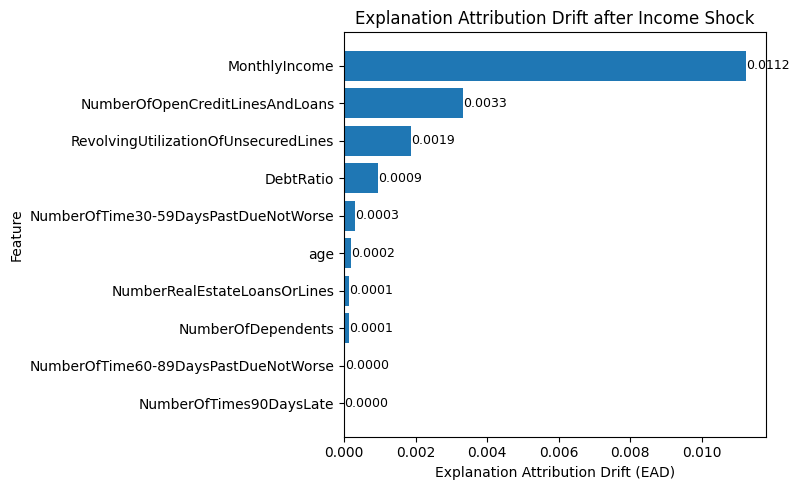

In [27]:
# ===============================
# Figure: Explanation Attribution Drift (Scenario A)
# ===============================

import matplotlib.pyplot as plt

# Sort by EAD
ead_plot = fad_income.sort_values("FAD", ascending=True)

plt.figure(figsize=(8,5))

plt.barh(
    ead_plot["Feature"],
    ead_plot["FAD"]
)

plt.xlabel("Explanation Attribution Drift (EAD)")
plt.ylabel("Feature")
plt.title("Explanation Attribution Drift after Income Shock")

# Add value labels
for i, value in enumerate(ead_plot["FAD"]):
    plt.text(
        value,
        i,
        f"{value:.4f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

# Save for the paper
plt.savefig("../figures/Figure_EAD_IncomeShock.png", dpi=300)

plt.show()

In [28]:
# ===============================
# Defeater-Sensitivity Index (DSI)
# ===============================

# Compute DSI as the mean Explanation Attribution Drift
dsi_income = fad_income["FAD"].mean()

print(f"Defeater-Sensitivity Index (Income Defeater): {dsi_income:.6f}")

Defeater-Sensitivity Index (Income Defeater): 0.001817


In [29]:
# ===============================
# Scenario B: Debt Shock
# ===============================

# Create a copy of the cleaned dataset
df_debt = df_clean.copy()

# Reproducibility
np.random.seed(42)

# Randomly select 30% of borrowers
debt_idx = df_debt.sample(frac=0.30, random_state=42).index

# Increase DebtRatio by 40%
df_debt.loc[debt_idx, "DebtRatio"] *= 1.40

print("Scenario B dataset created successfully.")
print(f"Borrowers affected: {len(debt_idx):,}")

Scenario B dataset created successfully.
Borrowers affected: 31,442


In [30]:
# ===============================
# SHAP Values for Debt Defeater
# ===============================

# Features only
X_debt = df_debt.drop(columns=["SeriousDlqin2yrs"])

# Use the same test indices as the original test set
X_test_debt = X_debt.loc[X_test.index]

# Compute SHAP values
debt_shap = explainer.shap_values(X_test_debt)

print("Scenario B SHAP values computed successfully.")

Scenario B SHAP values computed successfully.


In [31]:
# ===============================
# Explanation Attribution Drift (Debt Defeater)
# ===============================

# Mean absolute SHAP values
debt_mean = np.abs(debt_shap).mean(axis=0)

# Build comparison table
fad_debt = pd.DataFrame({
    "Feature": X_test.columns,
    "Baseline_SHAP": baseline_mean,
    "DebtShock_SHAP": debt_mean
})

# Explanation Attribution Drift
fad_debt["EAD"] = abs(
    fad_debt["Baseline_SHAP"] -
    fad_debt["DebtShock_SHAP"]
)

fad_debt = fad_debt.sort_values(
    by="EAD",
    ascending=False
)

fad_debt

,Feature,Baseline_SHAP,DebtShock_SHAP,EAD
3,DebtRatio,0.068698,0.072539,3.840758e-03
7,NumberRealEstateLoansOrLines,0.061073,0.062095,1.021961e-03
1,age,0.211223,0.212182,9.588561e-04
0,RevolvingUtilizationOfUnsecuredLines,0.576666,0.577324,6.580919e-04
5,NumberOfOpenCreditLinesAndLoans,0.114624,0.115078,4.538923e-04
2,NumberOfTime30-59DaysPastDueNotWorse,0.259902,0.260259,3.564821e-04
4,MonthlyIncome,0.078046,0.077754,2.916286e-04
6,NumberOfTimes90DaysLate,0.216386,0.216503,1.165012e-04
8,NumberOfTime60-89DaysPastDueNotWorse,0.110880,0.110902,2.121815e-05
9,NumberOfDependents,0.009908,0.009908,6.245172e-07


In [32]:
# ===============================
# Defeater-Sensitivity Index (Debt Defeater)
# ===============================

# Compute DSI
dsi_debt = fad_debt["EAD"].mean()

print(f"Defeater-Sensitivity Index (Debt Defeater): {dsi_debt:.6f}")

Defeater-Sensitivity Index (Debt Defeater): 0.000772


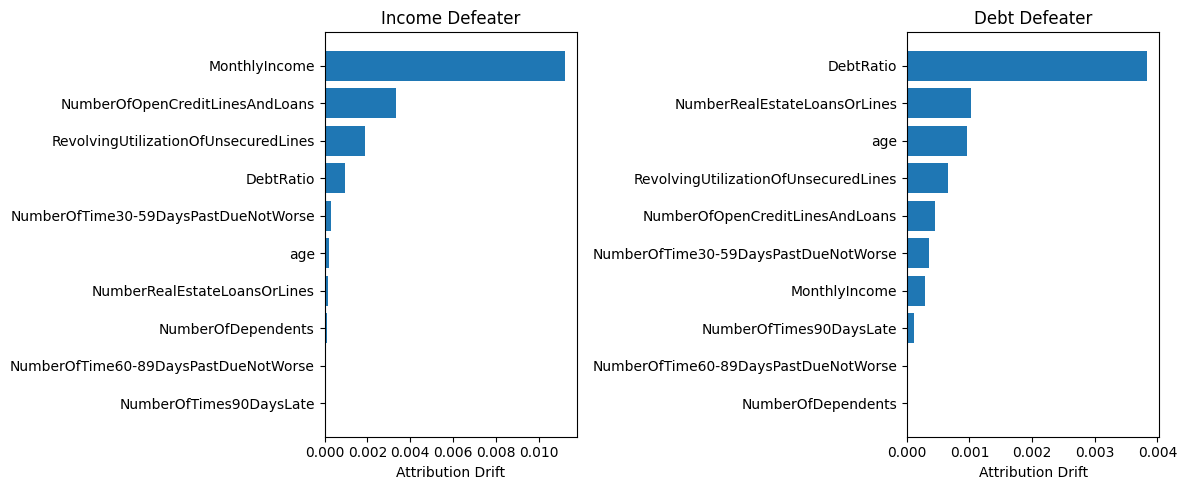

In [ ]:
# ============================================
# Figure: Comparison of Defeater Scenarios
# ============================================

import matplotlib.pyplot as plt

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# -----------------------
# Income Defeater
# -----------------------
income_plot = fad_income.sort_values("FAD", ascending=True)

axes[0].barh(
    income_plot["Feature"],
    income_plot["FAD"]
)

axes[0].set_title("Income Defeater")
axes[0].set_xlabel("Attribution Drift")

# -----------------------
# Debt Defeater
# -----------------------
debt_plot = fad_debt.sort_values("EAD", ascending=True)

axes[1].barh(
    debt_plot["Feature"],
    debt_plot["EAD"]
)

axes[1].set_title("Debt Defeater")
axes[1].set_xlabel("Attribution Drift")

plt.tight_layout()

plt.savefig(
    "../figures/Figure_Defeater_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show() 